# EDA Langer Wald — parc éolien virtuel

Langer Wald est un parc onshore allemand de 31 MW. L'analyse porte uniquement sur l'historique météo et la production virtuelle au pas de 15 minutes.

## Les données du site

La configuration fixe les hauteurs de vent disponibles, la hauteur du moyeu et le fuseau du marché allemand.

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / 'src').is_dir() and (candidate / 'config' / 'assets.yaml').is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError('Impossible de trouver la racine du projet Qair.')


from src.config import load_assets

site_config = load_assets(PROJECT_ROOT / 'config' / 'assets.yaml')['langer_wald']
historical_data = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'asset_data' / 'langer_wald_historical_reanalysis_15m.parquet'
)
historical_data['timestamp'] = pd.to_datetime(historical_data['timestamp'], utc=True)
historical_data = historical_data.sort_values('timestamp').reset_index(drop=True)

site_summary = pd.Series({
    'country': site_config['country'],
    'technology': site_config['technology'],
    'capacity_mw': site_config['capacity_mw'],
    'hub_height_m': site_config['hub_height_m'],
    'weather_source': 'ERA5 reanalysis',
    'rows': len(historical_data),
    'start_utc': historical_data['timestamp'].min(),
    'end_utc': historical_data['timestamp'].max(),
}, name='Langer Wald')
site_summary.to_frame()

,Langer Wald
country,Germany
technology,wind
capacity_mw,31
hub_height_m,166
weather_source,ERA5 reanalysis
rows,128640
start_utc,2023-01-01 00:00:00+00:00
end_utc,2026-09-01 23:45:00+00:00


---
## Continuité et valeurs manquantes

In [2]:
# Une différence de 15 minutes est attendue entre deux lignes successives.
timestamp_gaps = historical_data['timestamp'].diff().dropna()
quality_summary = pd.Series({
    'duplicate_timestamps': historical_data['timestamp'].duplicated().sum(),
    'missing_values': int(historical_data.isna().sum().sum()),
    'non_15_minute_gaps': int((timestamp_gaps != pd.Timedelta(minutes=15)).sum()),
    'production_below_zero': int((historical_data['production_mw'] < 0).sum()),
    'production_above_capacity': int(
        (historical_data['production_mw'] > site_config['capacity_mw']).sum()
    ),
})
quality_summary.to_frame('count')

,count
duplicate_timestamps,0
missing_values,0
non_15_minute_gaps,0
production_below_zero,0
production_above_capacity,0


La grille est complète : aucun doublon, aucun trou et aucune valeur hors des limites physiques.

---
## Niveau et disponibilité de la production

In [2]:
production_summary = historical_data['production_mw'].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).to_frame('production_mw')
production_summary.loc['mean_capacity_factor'] = historical_data['capacity_factor'].mean()
production_summary

,production_mw
count,128640.000000
mean,12.029861
std,10.563147
min,0.000000
5%,0.000000
25%,2.756169
50%,8.836504
75%,20.413769
95%,31.000000
max,31.000000


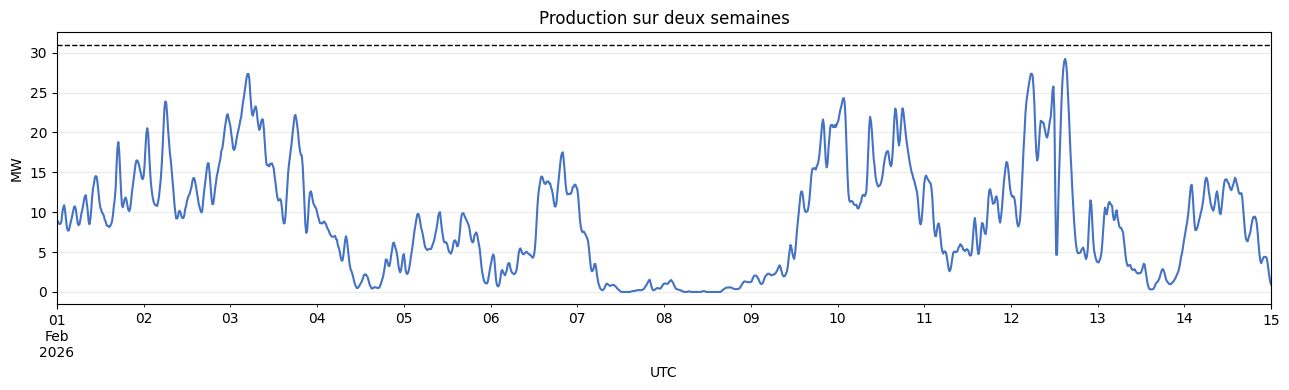

In [4]:
# Deux semaines permettent de voir les variations rapides sans écraser le détail.
sample = historical_data.loc[
    historical_data['timestamp'].between('2026-02-01', '2026-02-15')
]
ax = sample.plot(
    x='timestamp', y='production_mw', figsize=(13, 4), legend=False, color='#4472C4'
)
ax.axhline(site_config['capacity_mw'], color='black', linestyle='--', linewidth=1)
ax.set(title='Production sur deux semaines', xlabel='UTC', ylabel='MW')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

La production moyenne est de 12,03 MW, soit un facteur de charge moyen de 38,8 %. La médiane est de 8,84 MW et la production atteint 31 MW sur les périodes les plus ventées. La distribution reste déterministe, mais la réanalyse ERA5 fournit une variabilité météo plus crédible que l'ancien historique de forecast.

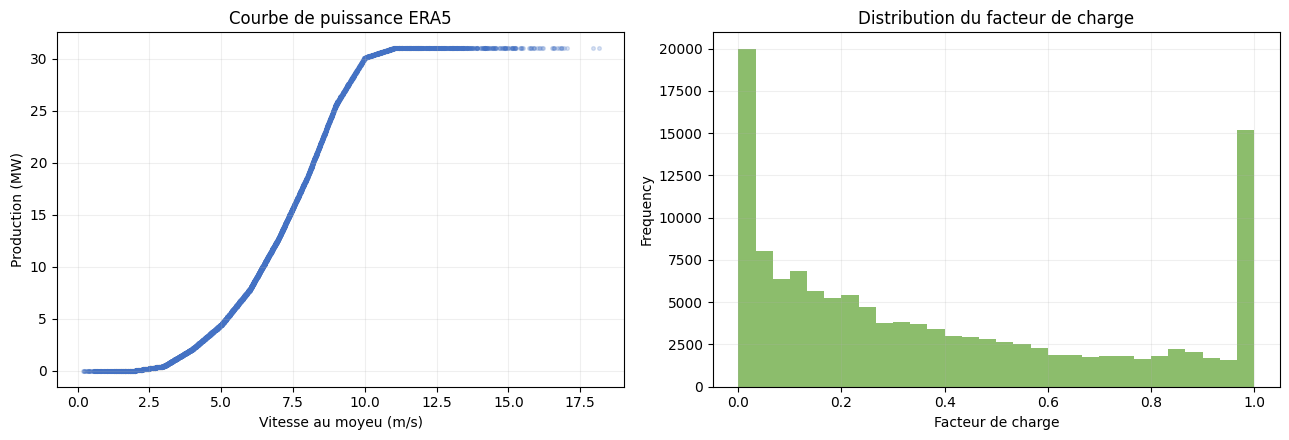

In [3]:
# La vitesse au moyeu est obtenue à partir de la vitesse ERA5 à 100 m.
wind_speed_100m = historical_data['wind_speed_100m']
historical_data['wind_speed_hub_m'] = wind_speed_100m * (
    site_config['hub_height_m'] / 100
) ** 0.2

curve_sample = historical_data.sample(n=min(8000, len(historical_data)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(
    curve_sample['wind_speed_hub_m'], curve_sample['production_mw'],
    s=7, alpha=0.2, color='#4472C4',
)
axes[0].set(xlabel='Vitesse au moyeu (m/s)', ylabel='Production (MW)', title='Courbe de puissance ERA5')
axes[0].grid(alpha=0.2)

historical_data['capacity_factor'].plot.hist(
    bins=30, ax=axes[1], color='#70AD47', alpha=0.8
)
axes[1].set(xlabel='Facteur de charge', title='Distribution du facteur de charge')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

Le nuage de points suit la courbe de puissance utilisée par le simulateur : la production augmente avec la vitesse au moyeu, puis atteint le plafond de 31 MW. Cette relation sera utile pour les modèles, mais elle reste plus propre que sur un parc réel où les arrêts, le bridage et les pertes créent davantage de dispersion.

,mean_production_mw,mean_capacity_factor,mean_hub_wind_mps
month,,,
1,17.775833,0.573414,8.061314
2,14.813335,0.477850,7.134747
3,11.512830,0.371382,6.190948
4,10.594567,0.341760,5.950036
5,7.327625,0.236375,5.197255
6,8.618237,0.278008,5.520927
7,8.800239,0.283879,5.564230
8,7.450611,0.240342,5.205908
9,11.395044,0.367582,6.089016


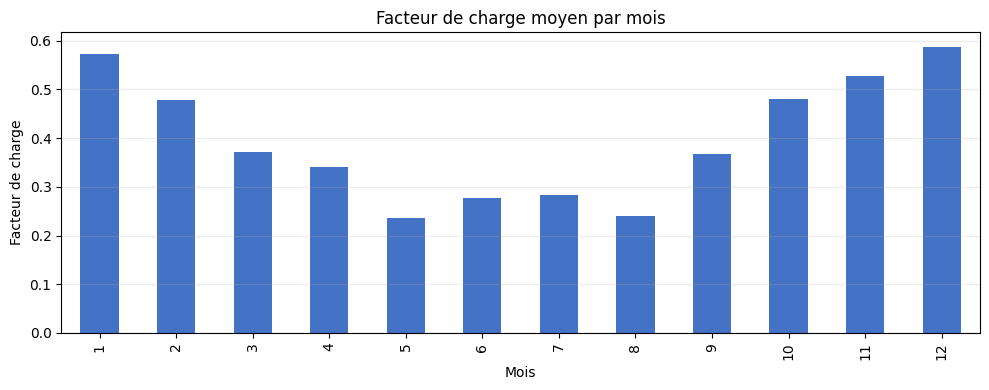

In [4]:
local_time = historical_data['timestamp'].dt.tz_convert(site_config['market_timezone'])
monthly_profile = (
    historical_data.assign(month=local_time.dt.month)
    .groupby('month')
    .agg(
        mean_production_mw=('production_mw', 'mean'),
        mean_capacity_factor=('capacity_factor', 'mean'),
        mean_hub_wind_mps=('wind_speed_hub_m', 'mean'),
    )
)
display(monthly_profile)
ax = monthly_profile[['mean_capacity_factor']].plot.bar(
    figsize=(10, 4), legend=False, color='#4472C4'
)
ax.set(title='Facteur de charge moyen par mois', xlabel='Mois', ylabel='Facteur de charge')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

Le facteur de charge est le plus élevé en décembre (58,8 %) et en janvier (57,3 %). Il descend autour de 24 % en mai et août. La saisonnalité est cohérente avec le cycle du vent dans cette réanalyse.

In [5]:
historical_data['wind_direction_100m'].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).to_frame('wind_direction_100m')

,wind_direction_100m
count,128640.000000
mean,200.946319
std,88.172737
min,0.000000
5%,34.000000
25%,143.449551
50%,211.000000
75%,264.249405
95%,332.250129
max,360.000000


,observations,mean_production_mw
direction_sector,,
000–030°,5652,5.870983
030–060°,6242,6.934487
060–090°,7662,7.988310
090–120°,7526,6.866108
120–150°,6577,5.650845
150–180°,8409,10.112619
180–210°,21333,16.878005
210–240°,19695,15.990751
240–270°,16145,16.105366


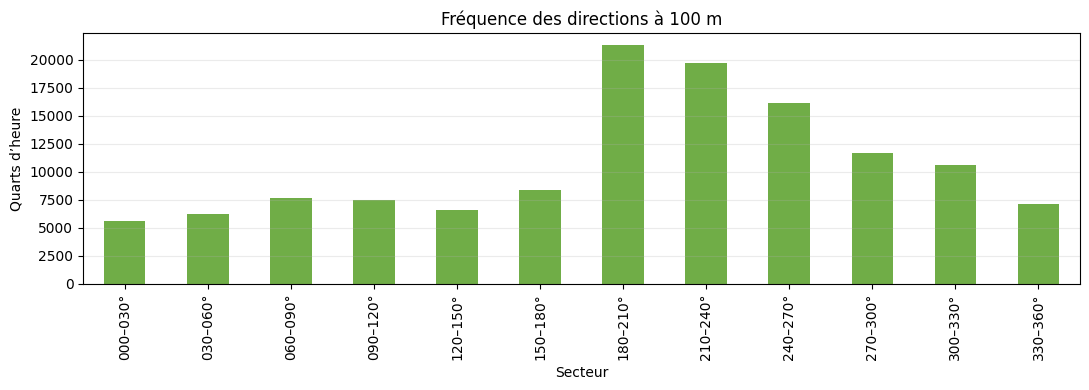

In [6]:
# Les secteurs de 30° rendent la direction plus lisible qu'une valeur angulaire brute.
direction_edges = np.arange(0, 361, 30)
direction_labels = [f'{start:03.0f}–{start + 30:03.0f}°' for start in direction_edges[:-1]]
direction_sector = pd.cut(
    historical_data['wind_direction_100m'] % 360,
    bins=direction_edges,
    labels=direction_labels,
    right=False,
    include_lowest=True,
)
direction_profile = (
    historical_data.assign(direction_sector=direction_sector)
    .groupby('direction_sector', observed=True)
    .agg(
        observations=('production_mw', 'size'),
        mean_production_mw=('production_mw', 'mean'),
    )
)
display(direction_profile)
ax = direction_profile['observations'].plot.bar(figsize=(11, 4), color='#70AD47')
ax.set(title='Fréquence des directions à 100 m', xlabel='Secteur', ylabel='Quarts d’heure')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

Les secteurs 180–270° sont à la fois les plus fréquents et les plus productifs dans cette réanalyse. Le secteur 180–210° concentre le plus d'observations et affiche environ 16,9 MW de production moyenne, contre environ 5,7 MW entre 120 et 150°. Cela décrit une association dans l'historique, pas un effet causal du secteur seul.

,absolute_ramp_mw
count,128639.000000
mean,0.384695
std,0.505312
min,0.000000
50%,0.211242
90%,0.979843
95%,1.371780
99%,2.341499
max,9.128803


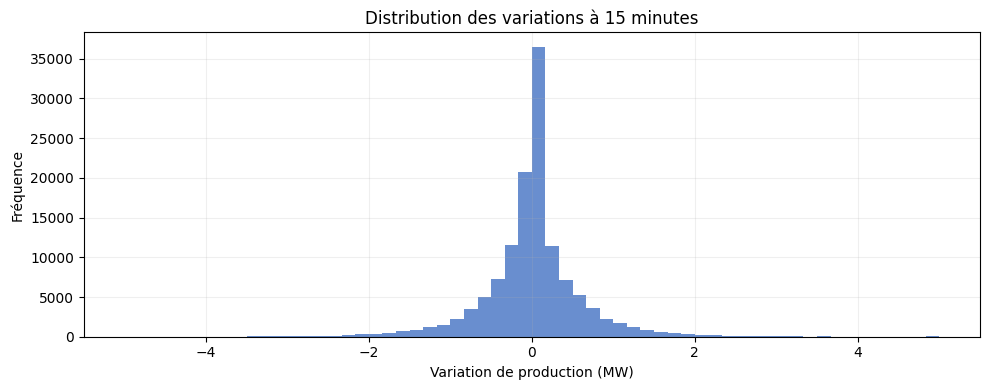

In [7]:
# Les variations de production sont calculées par différence entre deux lignes successives.
ramps_mw = historical_data['production_mw'].diff()
ramp_summary = ramps_mw.abs().describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
).to_frame('absolute_ramp_mw')
display(ramp_summary)

ax = ramps_mw.clip(-5, 5).plot.hist(
    bins=60, figsize=(10, 4), color='#4472C4', alpha=0.8
)
ax.set(title='Distribution des variations à 15 minutes', xlabel='Variation de production (MW)', ylabel='Fréquence')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

La variation absolue médiane est de 0,21 MW à 15 minutes ; 90 % des variations restent sous 0,98 MW et 99 % sous 2,34 MW. Le maximum atteint 9,13 MW. La série ERA5 reste donc lissée à cette échelle, même si elle est plus adaptée comme cible historique qu'un forecast rejoué.

La vitesse au moyeu reste la variable centrale du modèle. La direction et le cisaillement peuvent préciser le régime de vent, mais ils ne remplacent pas la variabilité fine qui manquerait encore dans une mesure réelle de parc.